# Parallel CNNs with Varied Loss Functions

This notebook will attempt to replicate the model and train it as described in the paper, and then with a better loss function.

In [1]:
# Setup & Load Data
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

device_2_data = pd.read_csv("processed-data/device_2_processed.csv").iloc[100:]
device_3_data = pd.read_csv("processed-data/device_3_processed.csv").iloc[100:]
device_4_data = pd.read_csv("processed-data/device_4_processed.csv").iloc[100:]
device_5_data = pd.read_csv("processed-data/device_5_processed.csv").iloc[100:]

# Normalize time for each device to count up from 0
device_2_data["time"] = device_2_data["timeEpoch"] - device_2_data["timeEpoch"].min()
device_3_data["time"] = device_3_data["timeEpoch"] - device_3_data["timeEpoch"].min()
device_4_data["time"] = device_4_data["timeEpoch"] - device_4_data["timeEpoch"].min()
device_5_data["time"] = device_5_data["timeEpoch"] - device_5_data["timeEpoch"].min()

# Calculate Delta Vth (baseline is first measurement after slicing)
device_2_data["Delta_Vt"] = device_2_data["Vt"] - device_2_data["Vt"].iloc[0]
device_3_data["Delta_Vt"] = device_3_data["Vt"] - device_3_data["Vt"].iloc[0]
device_4_data["Delta_Vt"] = device_4_data["Vt"] - device_4_data["Vt"].iloc[0]
device_5_data["Delta_Vt"] = device_5_data["Vt"] - device_5_data["Vt"].iloc[0]

# Normalize features to prevent activation explosion
# Compute statistics from training data
all_train = [device_3_data, device_4_data, device_5_data]
esw_mean = np.concatenate([d['Esw'].values for d in all_train]).mean()
esw_std = np.concatenate([d['Esw'].values for d in all_train]).std()
rth_mean = np.concatenate([d['Rth'].values for d in all_train]).mean()
rth_std = np.concatenate([d['Rth'].values for d in all_train]).std()
dv_mean = np.concatenate([d['Delta_Vt'].values for d in all_train]).mean()
dv_std = np.concatenate([d['Delta_Vt'].values for d in all_train]).std()

# Apply normalization to all datasets
for data in [device_2_data, device_3_data, device_4_data, device_5_data]:
    data["Esw"] = (data["Esw"] - esw_mean) / esw_std
    data["Rth"] = (data["Rth"] - rth_mean) / rth_std
    data["Delta_Vt"] = (data["Delta_Vt"] - dv_mean) / dv_std

# Use device 2 for dev, everything else for train
data_train = [device_3_data, device_4_data, device_5_data]
data_dev = device_2_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [66]:
# Model Definitions
rul_scale = 2000.0  # To normalize the RUL values to be bewteen 0 and 1, which Claude recommended might be a good idea...

# CausalConv written by Claude
class CausalConv1d(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation  # left-pad only
        self.conv = torch.nn.Conv1d(in_channels, out_channels,
                                    kernel_size, dilation=dilation, padding=0)
    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.pad, 0))
        return self.conv(x)

class RULModel(torch.nn.Module):
    """ Contains a CNN fed by Esw, an LSTM fed by Rth and Vt, and a cross attention layer that combines the CNN and LSTM outputs to predict RUL. """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int):
        super(RULModel, self).__init__()
        self.cnnconv1=    CausalConv1d(in_channels=1, out_channels=hidden_size, kernel_size=7, dilation=16)
        self.cnnconv2=    CausalConv1d(in_channels=hidden_size, out_channels=hidden_size, kernel_size=5, dilation=1)
        self.cnnrelu =    torch.nn.ReLU()
        self.cnnbn = torch.nn.BatchNorm1d(hidden_size)
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.attention = torch.nn.MultiheadAttention(embed_dim=hidden_size, num_heads=2, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

        self.cm_scale = torch.nn.Linear(1, 1)  # Scaling factor for coffin-manson predictions
        self.cm_material = torch.nn.Linear(1, 1)  # Scaling factor for coffin-manson predictions

    def forward(self, esw, rth_vt):
        # CNN branch for Esw
        # esw = esw.permute(0,2,1)  # Add channel dimension; suggested by Gemini
        # esw = esw.unsqueeze(1)  # Add channel dimension
        esw = esw.view(esw.size(0), 1, -1)  # Reshape to (1, 1, seq_len)
        rth_vt = rth_vt.view(rth_vt.size(0), -1, 2)  # Add batch dimension for LSTM

        cnn_out = self.cnnconv1(esw)
        cnn_out = self.cnnrelu(cnn_out)
        # cnn_out = self.cnnconv2(cnn_out)
        # cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnbn(cnn_out)
        cnn_out = cnn_out.transpose(1,2)  # (batch, seq_len, hidden_size)
        
        # LSTM branch for Rth and Vt
        lstm_out, _ = self.lstm(rth_vt)
        
        # Cross attention between CNN and LSTM outputs
        seq_len = cnn_out.size(1)
        causal_mask = torch.triu(  # Causal mask from Claude
            torch.ones(seq_len, seq_len, device=cnn_out.device), diagonal=1
        ).bool()  # True = masked out

        attn_output, _ = self.attention(
            cnn_out, lstm_out, lstm_out,
            attn_mask=causal_mask
        )
        
        # Final RUL prediction using fused attention output
        rul_pred = self.fc(attn_output)  # Per-timestep predictions: (batch, seq_len, 1)
        
        return rul_pred


In [67]:

def train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.001, fancyloss=False):

    if fancyloss:
        # Init weights to reasonable values so fancy loss is not at a disadvantage.
        torch.nn.init.constant_(model.cm_material.weight, -2.5)
        torch.nn.init.constant_(model.cm_material.bias, 0.0)
        # Initialize cm_scale to identity (slope=1, bias=0)
        torch.nn.init.constant_(model.cm_scale.weight, 1.0)
        torch.nn.init.constant_(model.cm_scale.bias, 0.0)


    mseloss = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    allloss = []

    # move things to the device:
    model.to(device)
    mseloss.to(device)
    # data_dev = data_dev.to(device)
    # data_train = [d.to(device) for d in data_train]

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for device_data in data_train:
            # window_size = np.random.randint(256, 2048)  # Random window size
            # Claude helped with trasforming my code from individual runs to batching, which speeds things up tremendously!
            # i=0
            # esw_batch = torch.stack([
            #     torch.tensor(device_data.iloc[i:i+window_size]['Esw'].values, dtype=torch.float32)
            #     for window_size in range(8, len(device_data))
            # ]).to(device)  # (batch_size, window_size)
            
            # rth_vt_batch = torch.stack([
            #     torch.tensor(device_data.iloc[i:i+window_size][['Rth', 'Delta_Vt']].values, dtype=torch.float32)
            #     for window_size in range(8, len(device_data))
            # ]).to(device)  # (batch_size, window_size, 2)
            
            # rul_batch = torch.tensor([
            #     device_data.iloc[i+window_size-1]['RUL'] / rul_scale
            #     for window_size in range(8, len(device_data))
            # ], dtype=torch.float32).to(device)  # (batch_size,)

            esw = torch.tensor(device_data['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt = torch.tensor(device_data[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # Get rul at the end of the window
            # rul = torch.tensor(device_data_window.iloc[-1]['RUL'], dtype=torch.float32).to(device) / rul_scale  # Normalize RUL to be between 0 and 1

            optimizer.zero_grad()
            # rul_pred = model(esw_batch, rth_vt_batch)
    
            rul_pred = model(esw, rth_vt)
            rul_true = torch.tensor(device_data['RUL'].values / rul_scale, dtype=torch.float32).to(device)  # (N,)
            
            # Use coffin-manson model
            # Subtract 25 degC from a sliding average of package temperature to get deltaT
            deltaT = torch.tensor(device_data['time_domain_packageTemperature'].values, dtype=torch.float32).to(device) - 25
            A = 0.1
            alpha = model.cm_material(torch.tensor([1.0], device=device)) if fancyloss else -2.5 # Learnable material parameter
            Nf = (A * deltaT.unsqueeze(-1) ** alpha)/ rul_scale

            loss = 0.7 * mseloss(rul_pred.squeeze(), rul_true) + 0.3 * torch.abs(rul_pred.squeeze() - model.cm_scale(Nf.view(-1, 1))).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate on development set (full sequence like training)
        model.eval()
        dev_loss = 0.0
        with torch.no_grad():
            data_dev_window = data_dev

            esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # Get full RUL sequence for dev set (not just final value)
            rul_dev_full = torch.tensor(data_dev_window['RUL'].values / rul_scale, dtype=torch.float32).to(device)
            rul_pred_dev = model(esw_dev, rth_vt_dev)

            # Use coffin-manson model
            # Subtract 25 degC from a sliding average of package temperature to get deltaT
            deltaT = torch.tensor(data_dev_window['time_domain_packageTemperature'].values, dtype=torch.float32).to(device) - 25
            A = .1
            alpha = model.cm_material(torch.tensor([1.0], device=device)) if fancyloss else -2.5  # Learnable material parameter
            Nf = (A * deltaT.unsqueeze(-1) ** alpha)/ rul_scale

            # Compute loss over full sequence like training
            dev_loss = 0.7 * mseloss(rul_pred_dev.squeeze(), rul_dev_full) + 0.3 * torch.abs(rul_pred_dev.squeeze()  - model.cm_scale(Nf.view(-1, 1))).mean()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(data_train):.4f}, Dev Loss: {dev_loss:.4f}")
        allloss += [(train_loss/len(data_train), dev_loss/len(data_dev))]

    return allloss

In [68]:
modela = RULModel(input_size=2, hidden_size=32, num_layers=2)
modelb = RULModel(input_size=2, hidden_size=32, num_layers=2)
modelb.load_state_dict(modela.state_dict())  # Start with same weights for fair comparison

lossa = train_model(modela, data_train, data_dev, num_epochs=256, learning_rate=0.0005, fancyloss=False)
lossb = train_model(modelb, data_train, data_dev, num_epochs=256, learning_rate=0.0005, fancyloss=True)

Epoch 1/256, Train Loss: 0.1368, Dev Loss: 0.1263
Epoch 2/256, Train Loss: 0.1332, Dev Loss: 0.1237
Epoch 3/256, Train Loss: 0.1304, Dev Loss: 0.1218
Epoch 4/256, Train Loss: 0.1283, Dev Loss: 0.1205
Epoch 5/256, Train Loss: 0.1267, Dev Loss: 0.1196
Epoch 6/256, Train Loss: 0.1256, Dev Loss: 0.1191
Epoch 7/256, Train Loss: 0.1249, Dev Loss: 0.1187
Epoch 8/256, Train Loss: 0.1243, Dev Loss: 0.1182
Epoch 9/256, Train Loss: 0.1236, Dev Loss: 0.1175
Epoch 10/256, Train Loss: 0.1228, Dev Loss: 0.1166
Epoch 11/256, Train Loss: 0.1219, Dev Loss: 0.1156
Epoch 12/256, Train Loss: 0.1209, Dev Loss: 0.1146
Epoch 13/256, Train Loss: 0.1198, Dev Loss: 0.1135
Epoch 14/256, Train Loss: 0.1186, Dev Loss: 0.1123
Epoch 15/256, Train Loss: 0.1172, Dev Loss: 0.1109
Epoch 16/256, Train Loss: 0.1156, Dev Loss: 0.1092
Epoch 17/256, Train Loss: 0.1136, Dev Loss: 0.1072
Epoch 18/256, Train Loss: 0.1114, Dev Loss: 0.1048
Epoch 19/256, Train Loss: 0.1091, Dev Loss: 0.1024
Epoch 20/256, Train Loss: 0.1071, Dev Lo

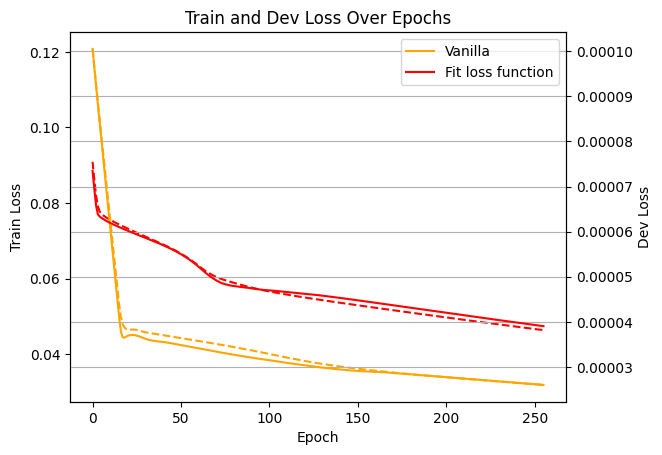

In [64]:
# plot train, dev loss on separate y-axes:
plt.title("Train and Dev Loss Over Epochs")
plt.xlabel("Epoch")
plt.plot([l[0] for l in lossa], label="Train Loss, Vanilla", linestyle='--', color='orange')
plt.plot([l[0] for l in lossb], label="Train Loss, Multiple Dilation", linestyle='--', color='red')
plt.ylabel("Train Loss")
plt.twinx()
plt.plot([l[1].cpu() for l in lossa], label="Vanilla", color='orange')
plt.plot([l[1].cpu() for l in lossb], label="Fit loss function", color='red')
plt.ylabel("Dev Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

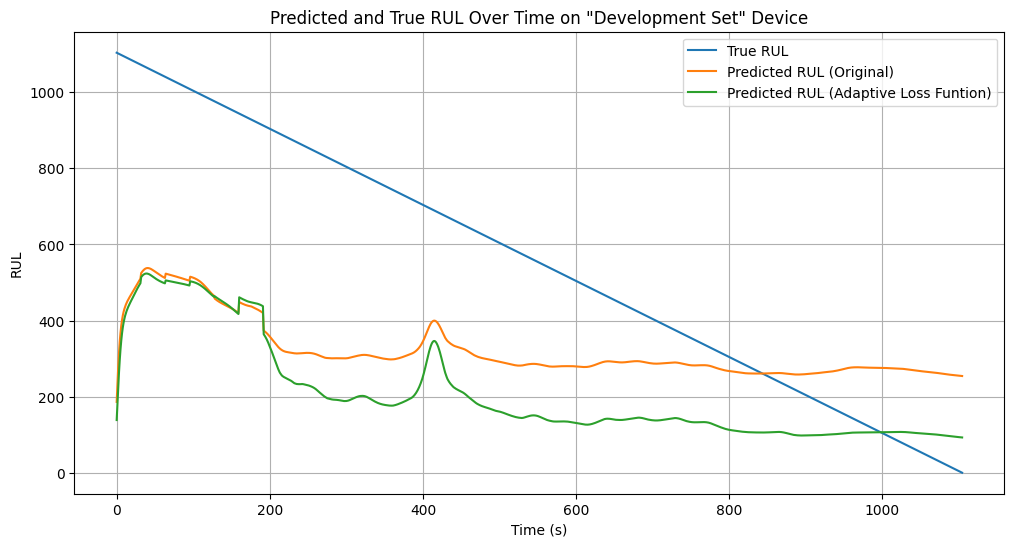

In [65]:
modela.eval()
modelb.eval()
with torch.no_grad():
    esw_dev = torch.tensor(data_dev['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
    rth_vt_dev = torch.tensor(data_dev[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)
    
    rula_pred_dev = modela(esw_dev, rth_vt_dev)  # (1, seq_len, 1)
    rulb_pred_dev = modelb(esw_dev, rth_vt_dev)  # (1, seq_len, 1)
    rul_true_dev = data_dev['RUL'].values  # (seq_len,)
    rula_pred_values = rula_pred_dev.squeeze().cpu().numpy() * rul_scale  # (seq_len,)
    rulb_pred_values = rulb_pred_dev.squeeze().cpu().numpy() * rul_scale  # (seq_len,)

# Also plot predicted and true side by side over time
plt.figure(figsize=(12, 6))
plt.plot(data_dev['time'], rul_true_dev, label="True RUL")
plt.plot(data_dev['time'], rula_pred_values, label="Predicted RUL (Original)")
plt.plot(data_dev['time'], rulb_pred_values, label="Predicted RUL (Adaptive Loss Funtion)")
plt.xlabel("Time (s)")
plt.ylabel("RUL")
plt.legend()
plt.title("Predicted and True RUL Over Time on \"Development Set\" Device")
plt.grid()
plt.show()